In [12]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score, accuracy_score

from imblearn.over_sampling import SMOTE

In [13]:
#Loading File
df = pd.read_csv("/content/credit_card_fraud_10k.csv")
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


is_fraud
0    9849
1     151
Name: count, dtype: int64


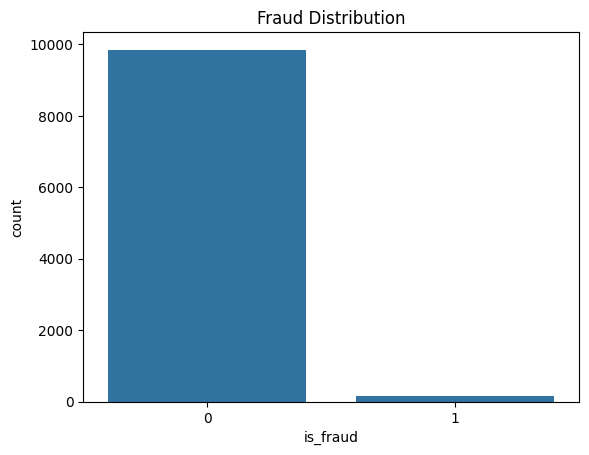

In [14]:
#Viewing Imbalance
print(df["is_fraud"].value_counts())
sns.countplot(data=df, x="is_fraud")
plt.title("Fraud Distribution")
plt.show()

In [15]:
#Feature-Target Separation
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [16]:
#One-Hot Encoding
X = pd.get_dummies(X, columns=["merchant_category"], drop_first=True)
X.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84.47,22,0,0,66,3,40,True,False,False,False
1,2,541.82,3,1,0,87,1,64,False,False,False,True
2,3,237.01,17,0,0,49,1,61,False,False,True,False
3,4,164.33,4,0,1,72,3,34,False,False,True,False
4,5,30.53,15,0,0,79,0,44,False,True,False,False


In [17]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
#Imbalance
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE")
print(y_train.value_counts())

print("After SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
is_fraud
0    7879
1     121
Name: count, dtype: int64
After SMOTE
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [19]:
#Model Training
model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_scaled)

In [20]:
#Model Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy: 0.979
Confusion Matrix:
[[1934   36]
 [   6   24]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.40      0.80      0.53        30

    accuracy                           0.98      2000
   macro avg       0.70      0.89      0.76      2000
weighted avg       0.99      0.98      0.98      2000

